# Dataset Statistics and Visualization

This notebook contains runnable versions of the code examples from `Chapter_Dataset_Statistics_and_Visualization.md`.

Some examples in the chapter use small made-up datasets. Others use the welding image dataset from `welding-python-fundamentals-assessment`. Run the cells from top to bottom so shared variables like `df`, `pixels`, and `pixel_df` are created before later examples use them.

## Setup

This cell imports the libraries used throughout the examples and finds the welding image dataset in this workspace.

If `pandas` is not installed in the active notebook environment, the cell installs it first because several chapter examples use `DataFrame`, `describe()`, `value_counts()`, `boxplot()`, and `skew()`.

In [23]:
%matplotlib inline

from pathlib import Path
import importlib.util
import subprocess
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_workspace_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'welding-python-fundamentals-assessment').exists():
            return candidate
    fallback = Path('/Users/marcomacias/Projects/IARL')
    if fallback.exists():
        return fallback
    return Path.cwd()


WORKSPACE_ROOT = find_workspace_root()
DATA_DIR = WORKSPACE_ROOT / 'welding-python-fundamentals-assessment' / 'data' / 'Welding Defect Detection.v1i.coco' / 'test'
ANNOTATION_PATH = DATA_DIR / '_annotations.coco.json'
IMAGE_PATHS = sorted(DATA_DIR.glob('*.jpg'))

if not IMAGE_PATHS:
    raise FileNotFoundError(f'No .jpg files found in {DATA_DIR}')

print('Workspace root:', WORKSPACE_ROOT)
print('Dataset dir:', DATA_DIR)
print('Images found:', len(IMAGE_PATHS))
print('Annotation file:', ANNOTATION_PATH)

Workspace root: /Users/marcomacias/Projects/IARL
Dataset dir: /Users/marcomacias/Projects/IARL/welding-python-fundamentals-assessment/data/Welding Defect Detection.v1i.coco/test
Images found: 21
Annotation file: /Users/marcomacias/Projects/IARL/welding-python-fundamentals-assessment/data/Welding Defect Detection.v1i.coco/test/_annotations.coco.json


## What are summary statistics?

In [2]:
brightness_values = [42, 45, 44, 41, 250, 43, 46]

count = len(brightness_values)
minimum = min(brightness_values)
maximum = max(brightness_values)
average = sum(brightness_values) / count

print(count)
print(minimum)
print(maximum)
print(average)

7
41
250
73.0


## Mean and median

In [3]:
values = [41, 42, 43, 44, 45, 46, 250]

mean_value = sum(values) / len(values)
median_value = sorted(values)[len(values) // 2]

print(mean_value)    # 73.0
print(median_value)  # 44

73.0
44


## Using pandas for tabular summaries

In [4]:
records = [
    {'image_id': 'img_001.png', 'defect_class': 'porosity', 'mean_pixel': 82.4},
    {'image_id': 'img_002.png', 'defect_class': 'crack', 'mean_pixel': 91.2},
    {'image_id': 'img_003.png', 'defect_class': 'porosity', 'mean_pixel': 77.8},
    {'image_id': 'img_004.png', 'defect_class': 'undercut', 'mean_pixel': 65.1},
]

df = pd.DataFrame(records)
print(df)

      image_id defect_class  mean_pixel
0  img_001.png     porosity        82.4
1  img_002.png        crack        91.2
2  img_003.png     porosity        77.8
3  img_004.png     undercut        65.1


In [5]:
print(df['mean_pixel'].describe())

count     4.000000
mean     79.125000
std      10.877921
min      65.100000
25%      74.625000
50%      80.100000
75%      84.600000
max      91.200000
Name: mean_pixel, dtype: float64


## Creating class counts

In [6]:
class_counts = df['defect_class'].value_counts()
print(class_counts)

defect_class
porosity    2
crack       1
undercut    1
Name: count, dtype: int64


In [7]:
class_percentages = df['defect_class'].value_counts(normalize=True) * 100
print(class_percentages)

defect_class
porosity    50.0
crack       25.0
undercut    25.0
Name: proportion, dtype: float64


## Class counts from folders

The chapter shows a `dataset/` folder with one subfolder per class. This cell creates a small temporary version of that folder structure so the example can run anywhere.

In [8]:
with tempfile.TemporaryDirectory() as tmpdir:
    dataset_dir = Path(tmpdir) / 'dataset'
    for class_name, file_count in {'crack': 2, 'porosity': 1, 'no_defect': 3}.items():
        class_dir = dataset_dir / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        for i in range(file_count):
            (class_dir / f'img_{i + 1:03}.png').write_text('placeholder')

    class_counts_from_folders = {}
    for class_dir in dataset_dir.iterdir():
        if class_dir.is_dir():
            image_files = list(class_dir.glob('*.png'))
            class_counts_from_folders[class_dir.name] = len(image_files)

print(class_counts_from_folders)

{'porosity': 1, 'crack': 2, 'no_defect': 3}


In [9]:
with tempfile.TemporaryDirectory() as tmpdir:
    dataset_dir = Path(tmpdir) / 'dataset'
    class_dir = dataset_dir / 'porosity'
    class_dir.mkdir(parents=True, exist_ok=True)
    for filename in ['img_001.png', 'img_002.jpg', 'img_003.jpeg']:
        (class_dir / filename).write_text('placeholder')

    image_files = (
        list(class_dir.glob('*.png'))
        + list(class_dir.glob('*.jpg'))
        + list(class_dir.glob('*.jpeg'))
    )

print([path.name for path in image_files])

['img_001.png', 'img_002.jpg', 'img_003.jpeg']


## Pixel values in images

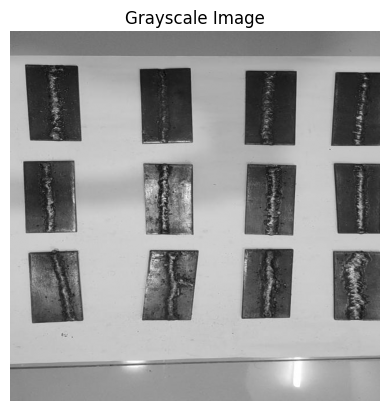

SampleV1_1_mp4-1_jpg.rf.3f50c974a91c4e6348dd49491f06def8.jpg
(640, 640)
0
255
146.14870361328124


In [27]:
image_path = IMAGE_PATHS[0]
image = Image.open(image_path).convert('L')  # L means grayscale
pixels = np.array(image)
plt.imshow(pixels, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()
print(image_path.name)
print(pixels.shape)
print(pixels.min())
print(pixels.max())
print(pixels.mean())

## Summarizing pixel values for one image

In [11]:
summary = {
    'min': pixels.min(),
    'max': pixels.max(),
    'mean': pixels.mean(),
    'median': np.median(pixels),
    'std': pixels.std(),
    'p01': np.percentile(pixels, 1),
    'p99': np.percentile(pixels, 99),
}

print(summary)

{'min': np.uint8(0), 'max': np.uint8(255), 'mean': np.float64(146.14870361328124), 'median': np.float64(171.0), 'std': np.float64(59.69946247131797), 'p01': np.float64(29.0), 'p99': np.float64(208.0)}


## Summarizing pixel values for many images

In [12]:
image_dir = DATA_DIR
rows = []

for image_path in image_dir.glob('*.jpg'):
    image = Image.open(image_path).convert('L')
    image_pixels = np.array(image)

    rows.append({
        'image_id': image_path.name,
        'height': image_pixels.shape[0],
        'width': image_pixels.shape[1],
        'min_pixel': image_pixels.min(),
        'max_pixel': image_pixels.max(),
        'mean_pixel': image_pixels.mean(),
        'median_pixel': np.median(image_pixels),
        'std_pixel': image_pixels.std(),
    })

pixel_df = pd.DataFrame(rows)
print(pixel_df.head())

                                            image_id  height  width  \
0  SampleV3_1_mp4-24_jpg.rf.017f90fdc7b6c9677feba...     640    640   
1  SampleV3_1_mp4-8_jpg.rf.15adb36ac87bf5e5533ced...     640    640   
2  SampleV2_2_mp4-39_jpg.rf.e18c2b9f47afa039f3f2f...     640    640   
3  SampleV2_2_mp4-71_jpg.rf.de0eaa495c44a7817fab2...     640    640   
4  SampleV2_2_mp4-59_jpg.rf.5e6543b79b7abac05cf80...     640    640   

   min_pixel  max_pixel  mean_pixel  median_pixel  std_pixel  
0          2        255  164.810044         185.0  49.693508  
1          0        254  159.574609         185.0  55.460016  
2          1        255  140.160581         152.0  58.106972  
3          1        254  134.758464         138.0  59.289729  
4          4        255  131.497410         131.0  55.585965  


In [13]:
print(pixel_df[['mean_pixel', 'std_pixel']].describe())

       mean_pixel  std_pixel
count   21.000000  21.000000
mean   140.801558  58.206898
std     13.528131   4.055007
min    119.593782  49.693508
25%    128.078328  55.460016
50%    136.959270  58.106972
75%    150.943096  59.744796
max    164.810044  67.862267


## Pixel distributions

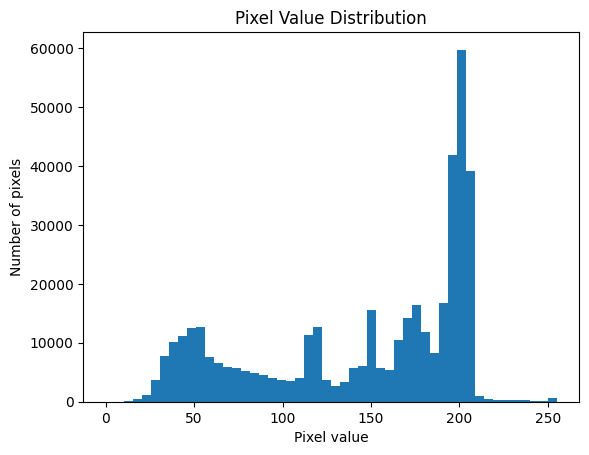

In [29]:
plt.hist(pixels.ravel(), bins=50)
plt.title('Pixel Value Distribution')
plt.xlabel('Pixel value')
plt.ylabel('Number of pixels')
plt.show()

## Plotting class counts

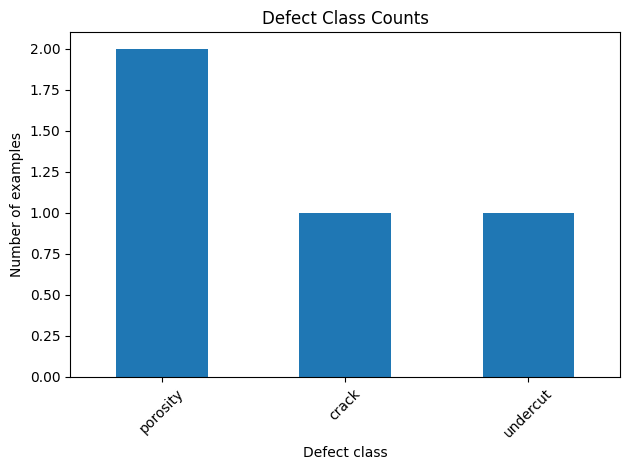

In [15]:
class_counts = df['defect_class'].value_counts()

class_counts.plot(kind='bar')
plt.title('Defect Class Counts')
plt.xlabel('Defect class')
plt.ylabel('Number of examples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plotting numeric distributions

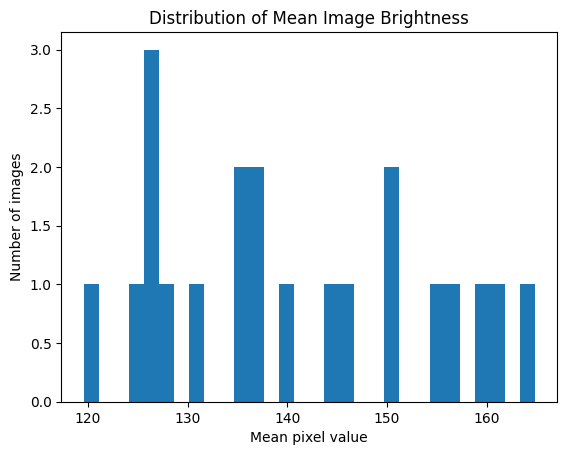

In [16]:
pixel_df['mean_pixel'].plot(kind='hist', bins=30)
plt.title('Distribution of Mean Image Brightness')
plt.xlabel('Mean pixel value')
plt.ylabel('Number of images')
plt.show()

## Box plots for spotting outliers

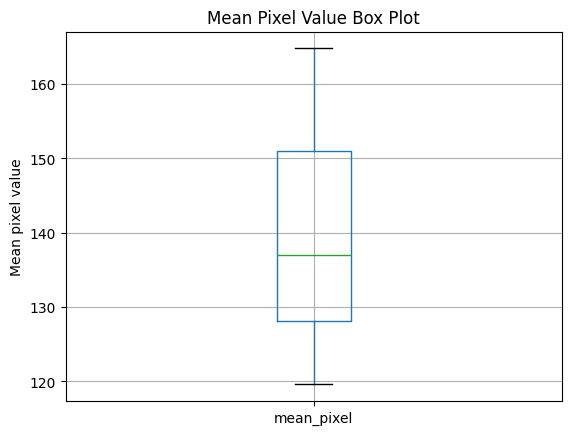

In [17]:
pixel_df.boxplot(column='mean_pixel')
plt.title('Mean Pixel Value Box Plot')
plt.ylabel('Mean pixel value')
plt.show()

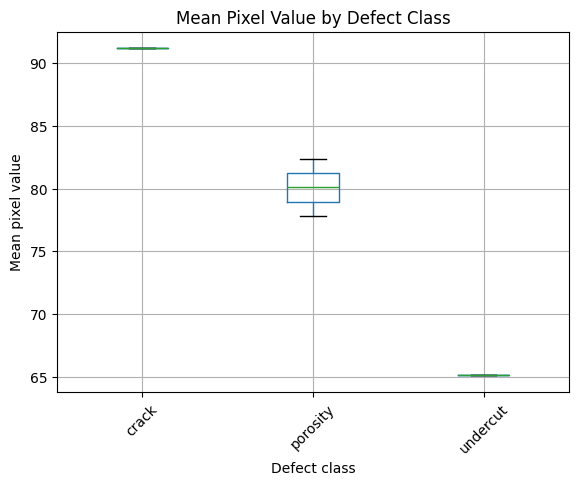

In [18]:
df.boxplot(column='mean_pixel', by='defect_class')
plt.title('Mean Pixel Value by Defect Class')
plt.suptitle('')
plt.xlabel('Defect class')
plt.ylabel('Mean pixel value')
plt.xticks(rotation=45)
plt.show()

## Scatter plots for relationships

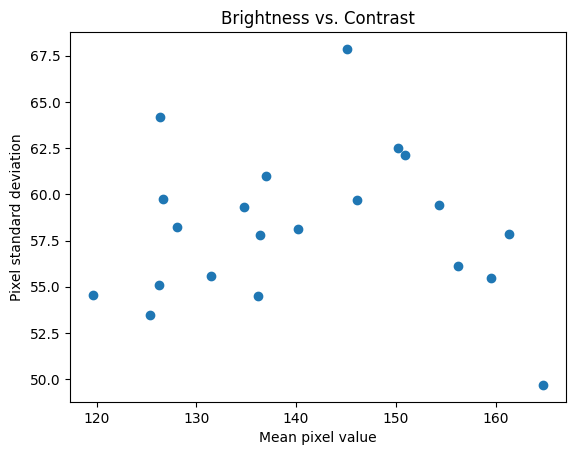

In [19]:
plt.scatter(pixel_df['mean_pixel'], pixel_df['std_pixel'])
plt.title('Brightness vs. Contrast')
plt.xlabel('Mean pixel value')
plt.ylabel('Pixel standard deviation')
plt.show()

## Line charts for trends

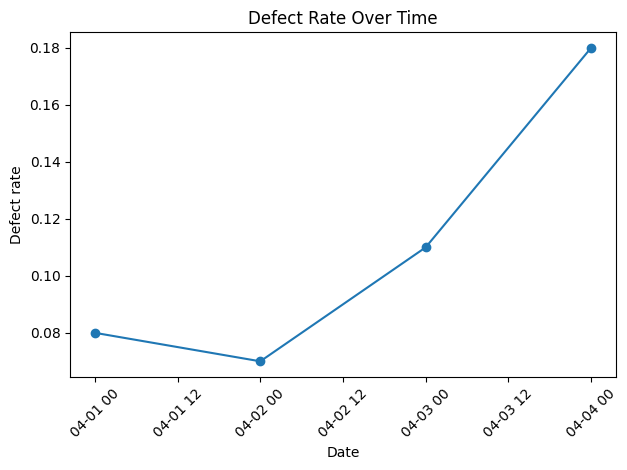

In [20]:
inspection_df = pd.DataFrame([
    {'date': '2026-04-01', 'defect_rate': 0.08},
    {'date': '2026-04-02', 'defect_rate': 0.07},
    {'date': '2026-04-03', 'defect_rate': 0.11},
    {'date': '2026-04-04', 'defect_rate': 0.18},
])

inspection_df['date'] = pd.to_datetime(inspection_df['date'])

plt.plot(inspection_df['date'], inspection_df['defect_rate'], marker='o')
plt.title('Defect Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Defect rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Outliers: mistakes or important examples?

In [21]:
bright_images = pixel_df[pixel_df['mean_pixel'] > 220]
print(bright_images)

Empty DataFrame
Columns: [image_id, height, width, min_pixel, max_pixel, mean_pixel, median_pixel, std_pixel]
Index: []


## Normalizing pixel values

In [22]:
pixels_float = pixels.astype('float32') / 255.0

print(pixels_float.min())
print(pixels_float.max())

0.0
1.0


## The normal distribution

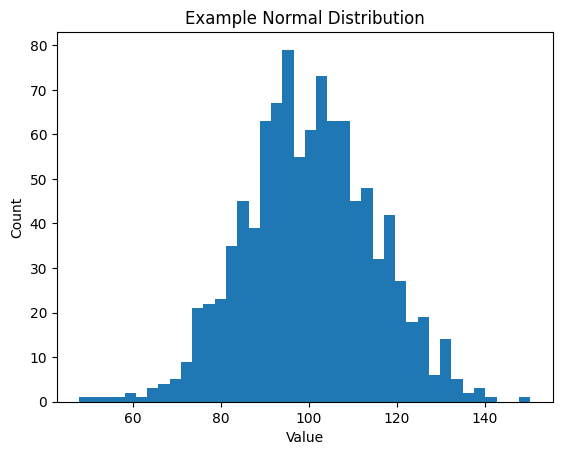

In [30]:
values = np.random.normal(loc=100, scale=15, size=1000)

plt.hist(values, bins=40)
plt.title('Example Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

## Gaussian and normal: two names, related idea

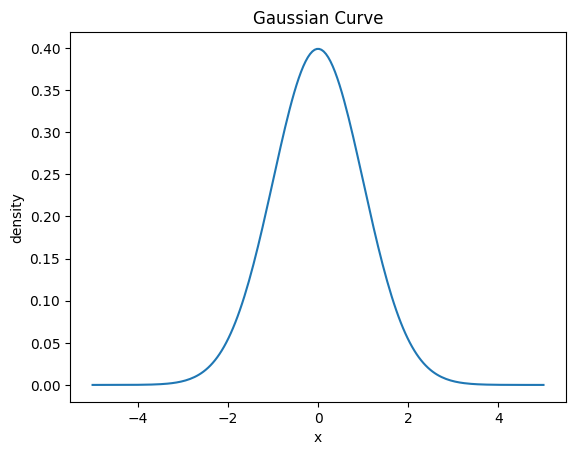

In [31]:
x = np.linspace(-5, 5, 200)
mean = 0
std = 1

y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

plt.plot(x, y)
plt.title('Gaussian Curve')
plt.xlabel('x')
plt.ylabel('density')
plt.show()

## The sigmoid function

In [32]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

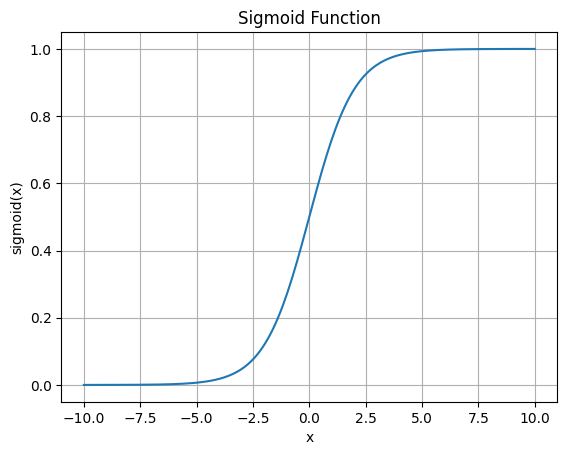

In [33]:
x = np.linspace(-10, 10, 200)
y = sigmoid(x)

plt.plot(x, y)
plt.title('Sigmoid Function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True)
plt.show()

In [34]:
raw_score = 2.2
probability = sigmoid(raw_score)

print(probability)

0.9002495108803148


## Skew

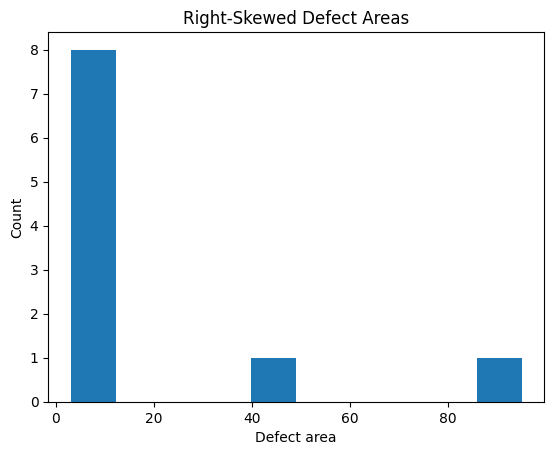

In [35]:
defect_areas = [3, 4, 4, 5, 6, 7, 8, 10, 40, 95]

plt.hist(defect_areas, bins=10)
plt.title('Right-Skewed Defect Areas')
plt.xlabel('Defect area')
plt.ylabel('Count')
plt.show()

## Mean vs. median with skew

In [36]:
defect_areas = np.array([3, 4, 4, 5, 6, 7, 8, 10, 40, 95])

print(defect_areas.mean())
print(np.median(defect_areas))

18.2
6.5


## Calculating skew in pandas

In [37]:
print(pixel_df['mean_pixel'].skew())

0.26471865220888224


## A practical dataset-checking workflow

In [38]:
def summarize_image_folder(image_dir):
    rows = []
    image_dir = Path(image_dir)

    for image_path in image_dir.glob('*.jpg'):
        image = Image.open(image_path).convert('L')
        image_pixels = np.array(image)

        rows.append({
            'image_id': image_path.name,
            'height': image_pixels.shape[0],
            'width': image_pixels.shape[1],
            'min_pixel': image_pixels.min(),
            'max_pixel': image_pixels.max(),
            'mean_pixel': image_pixels.mean(),
            'median_pixel': np.median(image_pixels),
            'std_pixel': image_pixels.std(),
            'p01_pixel': np.percentile(image_pixels, 1),
            'p99_pixel': np.percentile(image_pixels, 99),
        })

    return pd.DataFrame(rows)


summary_df = summarize_image_folder(DATA_DIR)
print(summary_df.describe())

       height  width  min_pixel   max_pixel  mean_pixel  median_pixel  \
count    21.0   21.0  21.000000   21.000000   21.000000     21.000000   
mean    640.0  640.0   3.523810  253.714286  140.801558    152.619048   
std       0.0    0.0   4.770944    2.813234   13.528131     30.678129   
min     640.0  640.0   0.000000  243.000000  119.593782    100.000000   
25%     640.0  640.0   1.000000  254.000000  128.078328    125.000000   
50%     640.0  640.0   2.000000  255.000000  136.959270    148.000000   
75%     640.0  640.0   4.000000  255.000000  150.943096    185.000000   
max     640.0  640.0  21.000000  255.000000  164.810044    194.000000   

       std_pixel  p01_pixel   p99_pixel  
count  21.000000  21.000000   21.000000  
mean   58.206898  31.523810  223.000000  
std     4.055007   5.895923    7.496666  
min    49.693508  23.000000  208.000000  
25%    55.460016  28.000000  216.000000  
50%    58.106972  30.000000  223.000000  
75%    59.744796  35.000000  227.000000  
max   